<h1 style="text-align: center; color: #2c3e50; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; font-weight: bold; border-bottom: 4px solid #3498db; padding-bottom: 10px;"> 📡 TelecomX: Customer Churn Prediction Pipeline </h1>
<p style="text-align: center; color: #7f8c8d; font-style: italic;"> Análisis avanzado de retención de clientes y modelado predictivo de Machine Learning </p>

# <div style="background-color: #2c3e50; color: #ecf0f1; padding: 15px; border-radius: 8px; border-left: 10px solid #3498db;"> ⚙️ Configuración del Entorno </div>

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import streamlit as st
import warnings
import os
warnings.filterwarnings('ignore')

# Configuración de estilo global
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# <div style="background-color: #2c3e50; color: #ecf0f1; padding: 15px; border-radius: 8px; border-left: 10px solid #3498db;"> 📥 Carga y Exploración de Datos </div>

In [61]:
# Carga del dataset aplanado
df = pd.read_csv('../data/raw/TelecomX_Data_flat.csv')

# Visualización del dataframe
df.head()

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


In [62]:
# Mostrar todas las columnas disponibles
df.columns.tolist()

['customerID',
 'Churn',
 'customer_gender',
 'customer_SeniorCitizen',
 'customer_Partner',
 'customer_Dependents',
 'customer_tenure',
 'phone_PhoneService',
 'phone_MultipleLines',
 'internet_InternetService',
 'internet_OnlineSecurity',
 'internet_OnlineBackup',
 'internet_DeviceProtection',
 'internet_TechSupport',
 'internet_StreamingTV',
 'internet_StreamingMovies',
 'account_Contract',
 'account_PaperlessBilling',
 'account_PaymentMethod',
 'account_Charges_Monthly',
 'account_Charges_Total']

# <div style="background-color: #2c3e50; color: #ecf0f1; padding: 15px; border-radius: 8px; border-left: 10px solid #3498db;"> 🧹 Limpieza y Calidad de Datos </div>

In [77]:
# --- LIMPIEZA DE DATOS ---

# 1. Manejo de valores nulos en 'account_Charges_Total'
df['account_Charges_Total'] = df['account_Charges_Total'].fillna(0)
df = df.dropna(subset=['Churn'])

# 2. Verificación de nulos
null_counts = df.isnull().sum()
print("Conteo de nulos por columna:")
print(null_counts[null_counts > 0] if null_counts.any() else "No hay valores nulos")

# 3. Verificación de tipos de datos
df.dtypes

Conteo de nulos por columna:
No hay valores nulos


customerID                                           str
Churn                                            float64
customer_gender                                    int64
customer_SeniorCitizen                             int64
customer_Partner                                   int64
customer_Dependents                                int64
customer_tenure                                    int64
phone_PhoneService                                 int64
account_PaperlessBilling                           int64
account_Charges_Monthly                          float64
account_Charges_Total                            float64
phone_MultipleLines_No phone service               int64
phone_MultipleLines_Yes                            int64
internet_InternetService_Fiber optic               int64
internet_InternetService_No                        int64
internet_OnlineSecurity_No internet service        int64
internet_OnlineSecurity_Yes                        int64
internet_OnlineBackup_No intern

# <div style="background-color: #2c3e50; color: #ecf0f1; padding: 15px; border-radius: 8px; border-left: 10px solid #3498db;"> 🛠️ Ingeniería de Características </div>

In [78]:
# --- INGENIERÍA DE CARACTERÍSTICAS: Conversión de variables binarias ---

def encode_binary_columns(dataframe):
    """
    Identifica y convierte columnas binarias a 1/0.
    """
    df_encoded = dataframe.copy()
    binary_cols = []
    
    mappings = {
        'Yes': 1, 'No': 0,
        'True': 1, 'False': 0,
        'Male': 1, 'Female': 0,
        True: 1, False: 0
    }
    
    for col in df_encoded.select_dtypes(include=['object', 'bool']).columns:
        unique_vals = set(df_encoded[col].dropna().unique())
        if len(unique_vals) == 2 and any(val in mappings for val in unique_vals):
            df_encoded[col] = df_encoded[col].map(mappings)
            binary_cols.append(col)
            
    return df_encoded, binary_cols

df, bin_cols = encode_binary_columns(df)
print(f"Columnas binarias convertidas: {bin_cols}")

Columnas binarias convertidas: []


In [79]:
# --- INGENIERÍA DE CARACTERÍSTICAS: One-Hot Encoding ---

def apply_one_hot_encoding(dataframe, columns_to_encode):
    """
    Aplica One-Hot Encoding a variables multiclase.
    """
    return pd.get_dummies(dataframe, columns=columns_to_encode, drop_first=True, dtype=int)

multiclass_cols = [col for col in df.select_dtypes(include=['object']).columns if col != 'customerID']
print(f"Aplicando One-Hot Encoding a: {multiclass_cols}")
df = apply_one_hot_encoding(df, multiclass_cols)

Aplicando One-Hot Encoding a: []


# <div style="background-color: #2c3e50; color: #ecf0f1; padding: 15px; border-radius: 8px; border-left: 10px solid #3498db;"> 📊 Análisis Exploratorio de Datos (EDA) </div>

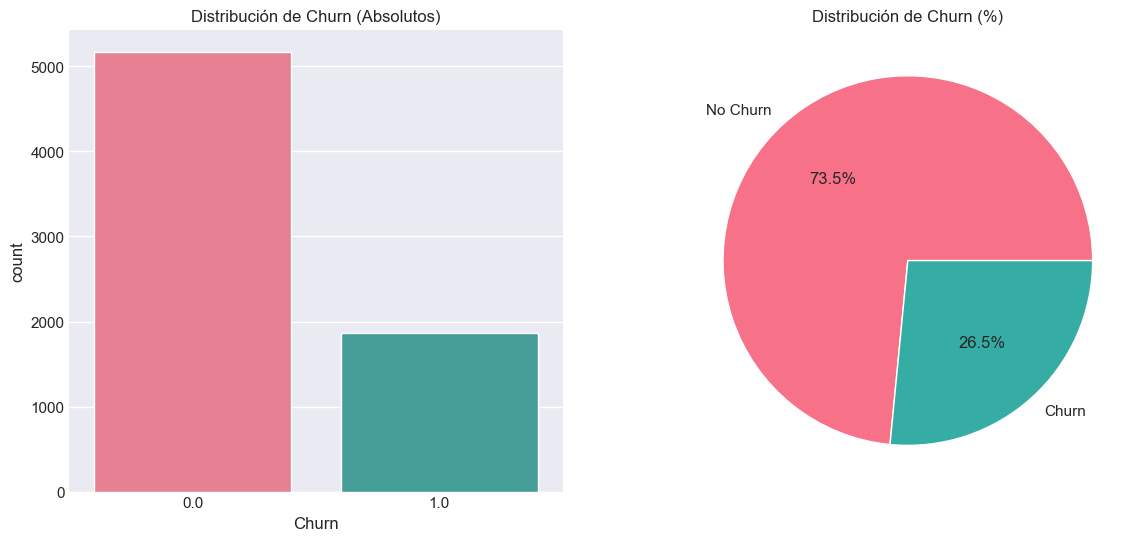

In [80]:
# --- EDA: Distribución general de Churn ---
os.makedirs('../docs/graficos/eda/', exist_ok=True)
plt.style.use('seaborn-v0_8-darkgrid')

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
sns.countplot(x='Churn', data=df, palette='husl', ax=ax[0])
ax[0].set_title('Distribución de Churn (Absolutos)')

churn_counts = df['Churn'].value_counts()
ax[1].pie(churn_counts, labels=['No Churn', 'Churn'], autopct='%1.1f%%', colors=sns.color_palette('husl', 2))
ax[1].set_title('Distribución de Churn (%)')

plt.savefig('../docs/graficos/eda/distribucion_churn.png')
plt.show()

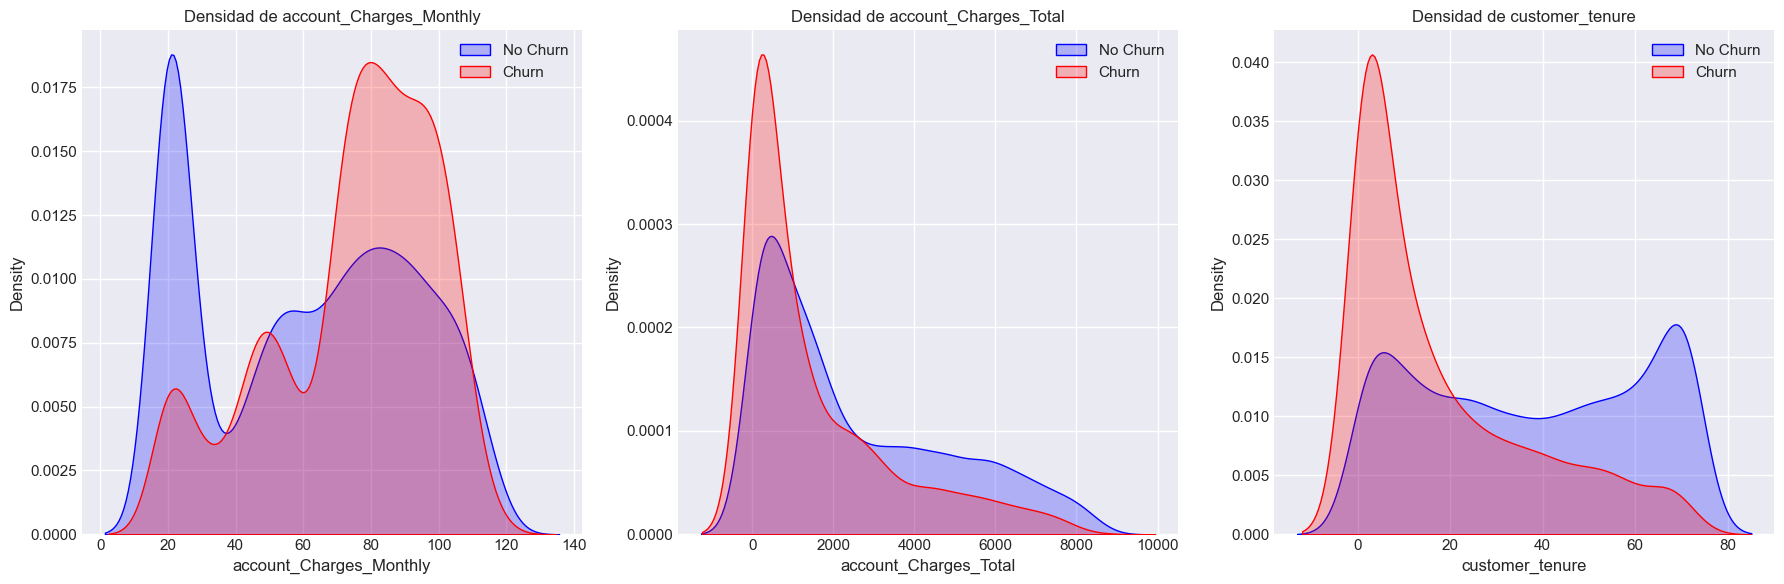

In [81]:
# --- EDA: Densidad de variables numéricas ---
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
vars_num = ['account_Charges_Monthly', 'account_Charges_Total', 'customer_tenure']

for i, var in enumerate(vars_num):
    sns.kdeplot(data=df[df['Churn'] == 0][var], ax=ax[i], fill=True, label='No Churn', color='blue')
    sns.kdeplot(data=df[df['Churn'] == 1][var], ax=ax[i], fill=True, label='Churn', color='red')
    ax[i].set_title(f'Densidad de {var}')
    ax[i].legend()

plt.tight_layout()
plt.savefig('../docs/graficos/eda/densidad_numerica.png')
plt.show()

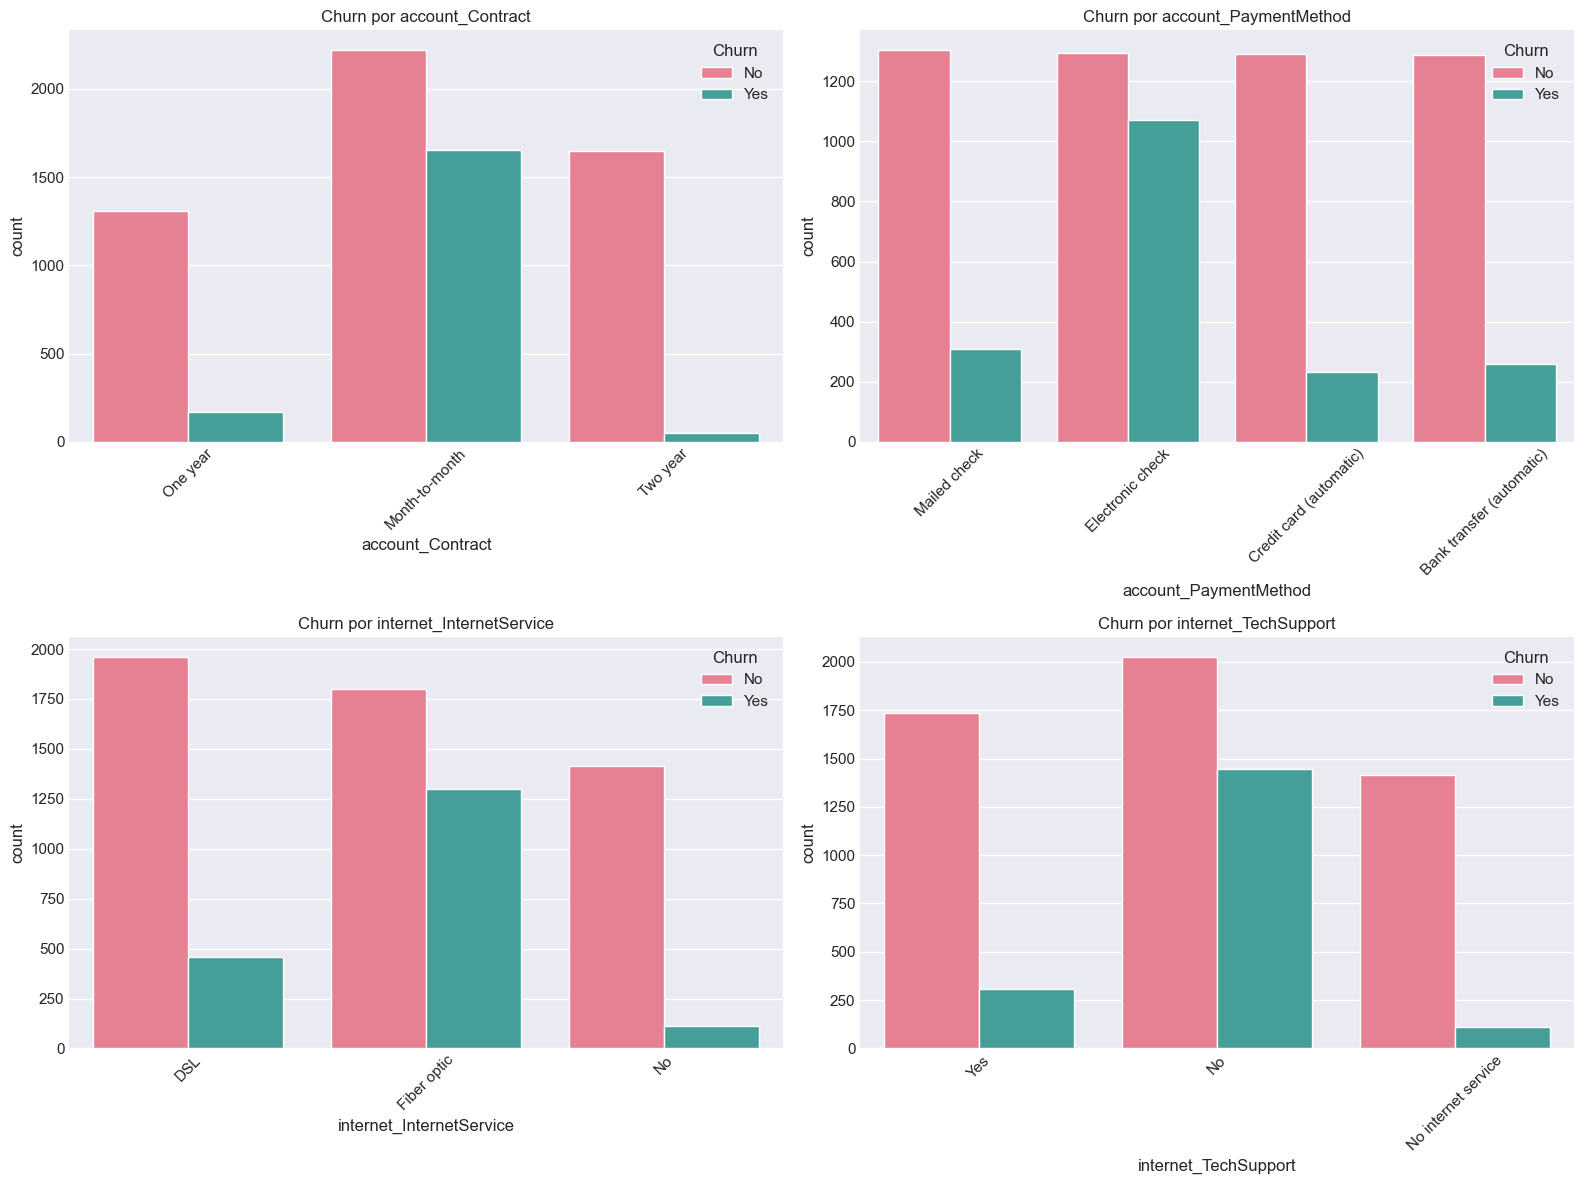

In [82]:
# --- EDA: Distribución por variables categóricas ---
df_viz = pd.read_csv('../data/raw/TelecomX_Data_flat.csv')
cat_vars = ['account_Contract', 'account_PaymentMethod', 'internet_InternetService', 'internet_TechSupport']

fig, ax = plt.subplots(2, 2, figsize=(16, 12))
ax = ax.flatten()

for i, var in enumerate(cat_vars):
    sns.countplot(x=var, hue='Churn', data=df_viz, palette='husl', ax=ax[i])
    ax[i].set_title(f'Churn por {var}')
    ax[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../docs/graficos/eda/distribucion_categorica.png')
plt.show()

# <div style="background-color: #2c3e50; color: #ecf0f1; padding: 15px; border-radius: 8px; border-left: 10px solid #3498db;"> 🔗 Análisis Estadístico de Correlación </div>

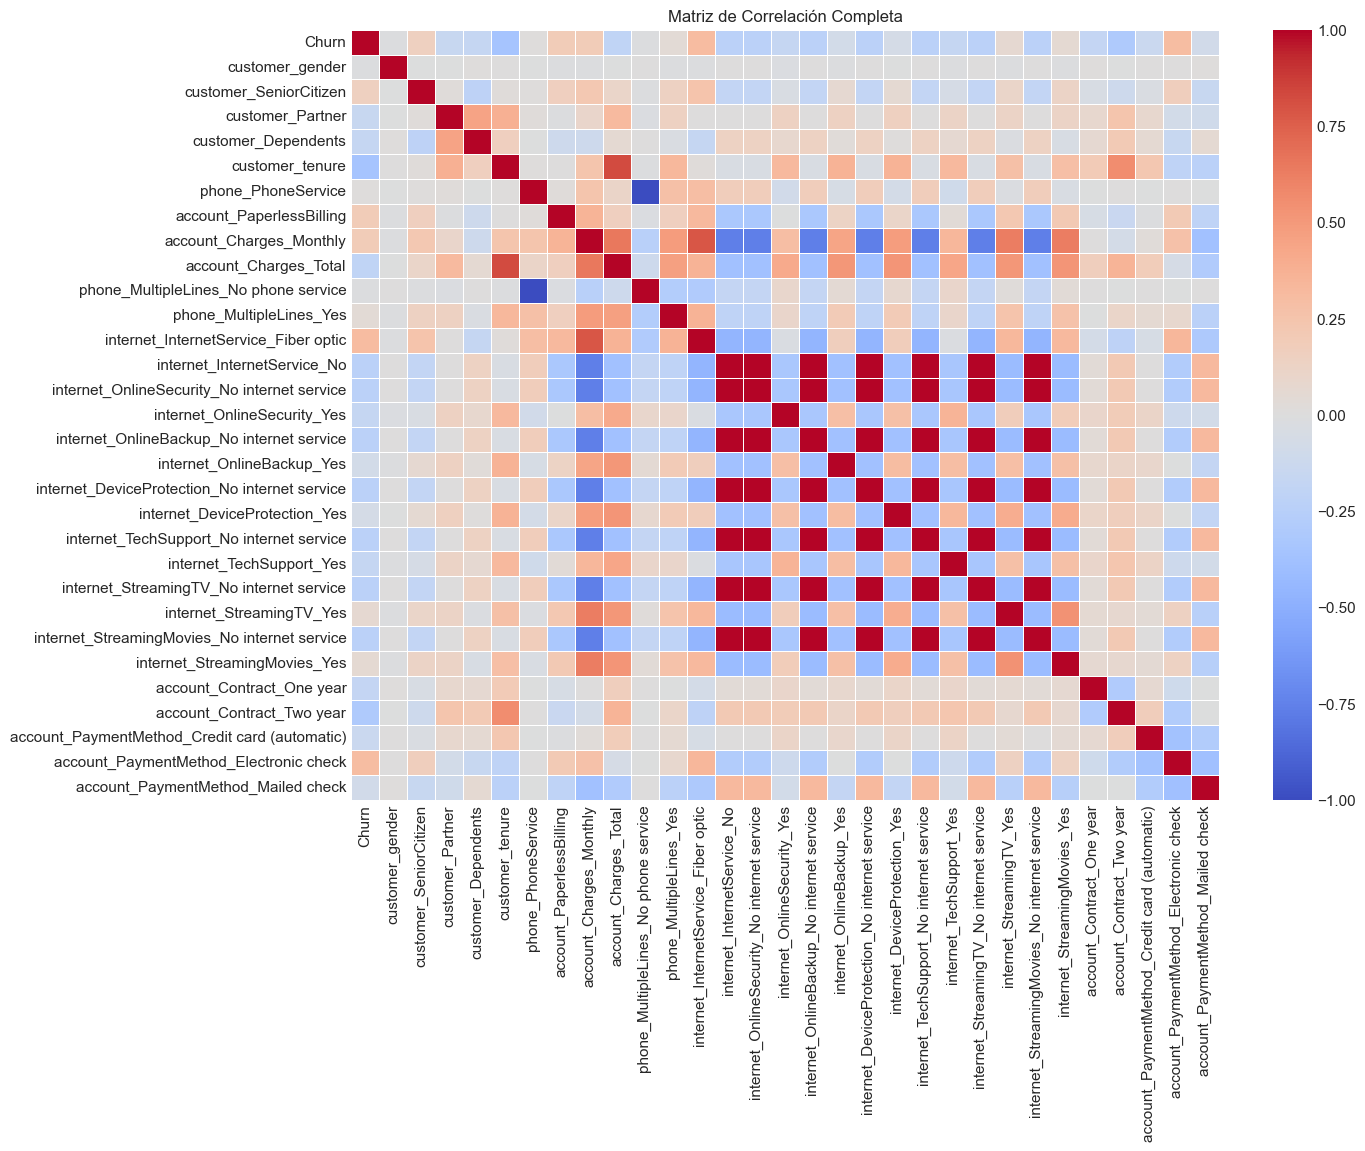

Top 10 variables con mayor correlación absoluta con Churn:
Churn                                           1.000000
customer_tenure                                 0.352229
internet_InternetService_Fiber optic            0.308020
account_Contract_Two year                       0.302253
account_PaymentMethod_Electronic check          0.301919
internet_OnlineBackup_No internet service       0.227890
internet_StreamingMovies_No internet service    0.227890
internet_StreamingTV_No internet service        0.227890
internet_TechSupport_No internet service        0.227890
internet_InternetService_No                     0.227890
internet_OnlineSecurity_No internet service     0.227890
Name: Churn, dtype: float64


In [83]:
# --- CORRELACIÓN: Matriz de correlación ---
os.makedirs('../docs/graficos/correlacion/', exist_ok=True)

plt.figure(figsize=(14, 10))
corr_matrix = df.drop(columns=['customerID']).corr()

sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación Completa')
plt.savefig('../docs/graficos/correlacion/matriz_calor.png')
plt.show()

print("Top 10 variables con mayor correlación absoluta con Churn:")
print(corr_matrix['Churn'].abs().sort_values(ascending=False).head(11))

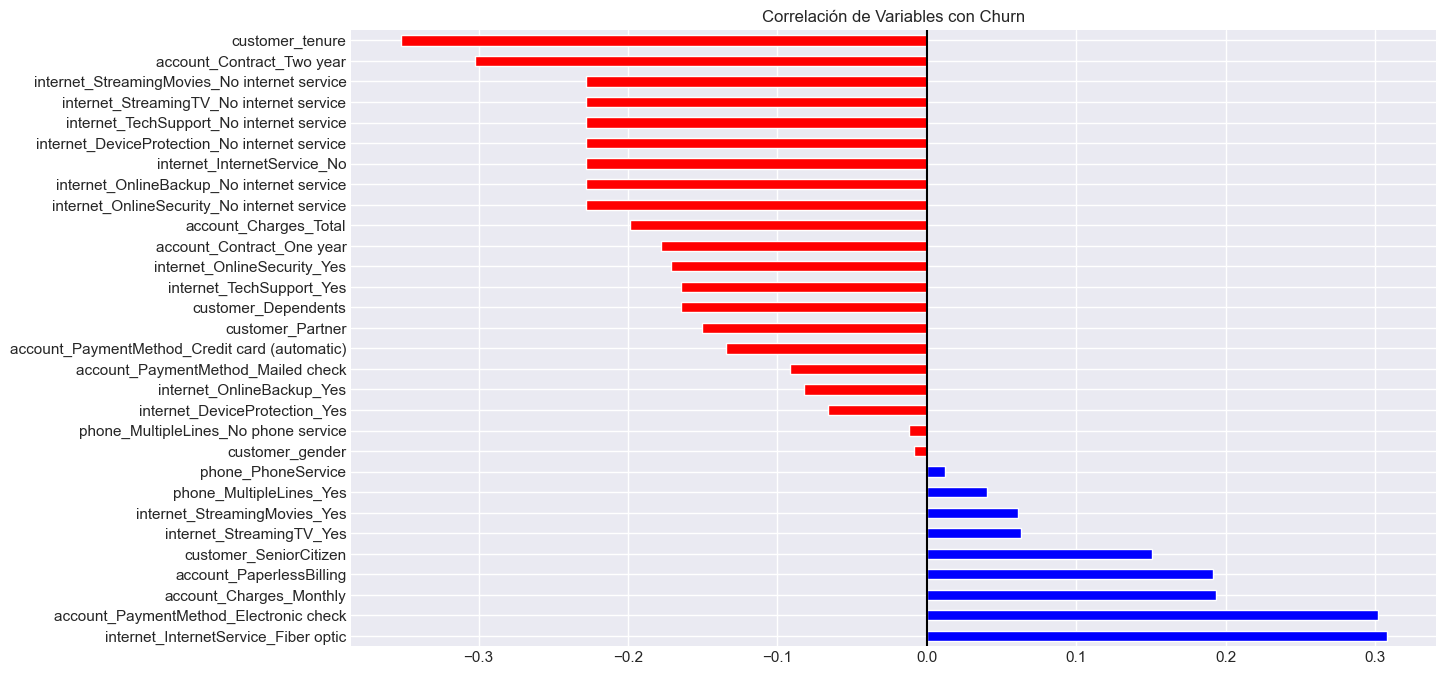

In [84]:
# --- CORRELACIÓN: Correlación con Churn ---
plt.figure(figsize=(14, 8))
churn_corr = corr_matrix['Churn'].sort_values(ascending=False).drop('Churn')

colors = ['red' if x < 0 else 'blue' for x in churn_corr.values]
churn_corr.plot(kind='barh', color=colors)
plt.title('Correlación de Variables con Churn')
plt.axvline(x=0, color='black', linestyle='-')
plt.savefig('../docs/graficos/correlacion/correlacion_churn_barras.png')
plt.show()

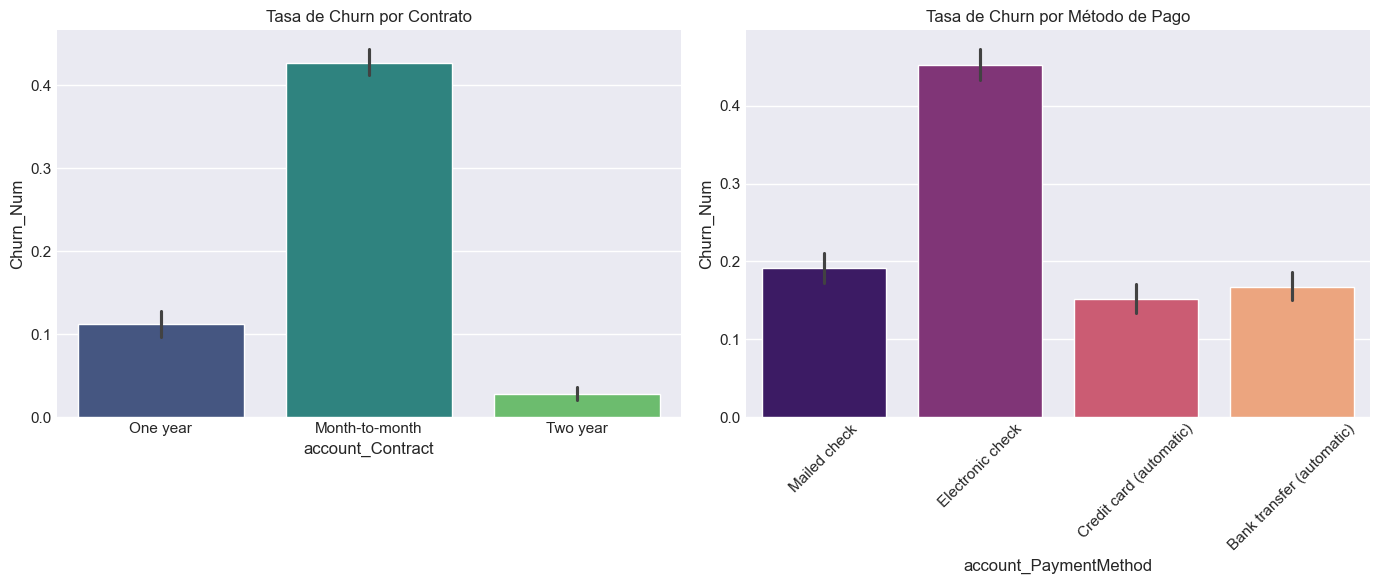

In [85]:
# --- CORRELACIÓN: Análisis por variable categórica (Tasa de Churn) ---
df_viz['Churn_Num'] = df_viz['Churn'].map({'Yes': 1, 'No': 0, 'True': 1, 'False': 0, 1: 1, 0: 0})

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(x='account_Contract', y='Churn_Num', data=df_viz, ax=ax[0], palette='viridis')
ax[0].set_title('Tasa de Churn por Contrato')

sns.barplot(x='account_PaymentMethod', y='Churn_Num', data=df_viz, ax=ax[1], palette='magma')
ax[1].set_title('Tasa de Churn por Método de Pago')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('../docs/graficos/correlacion/analisis_categorico.png')
plt.show()

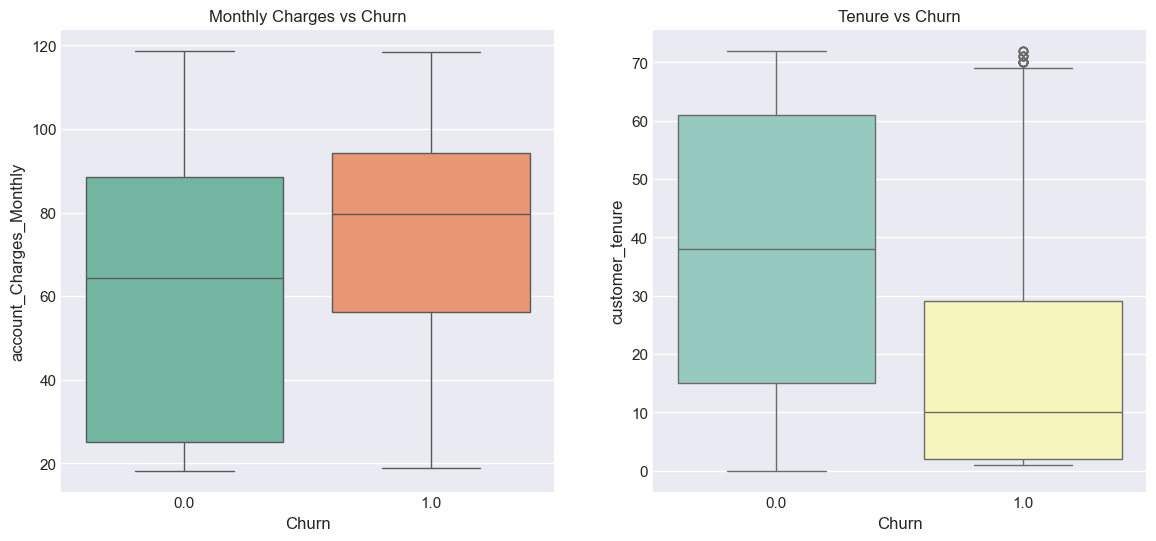

In [86]:
# --- CORRELACIÓN: Análisis por variables numéricas (Boxplots) ---
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(x='Churn', y='account_Charges_Monthly', data=df, ax=ax[0], palette='Set2')
ax[0].set_title('Monthly Charges vs Churn')

sns.boxplot(x='Churn', y='customer_tenure', data=df, ax=ax[1], palette='Set3')
ax[1].set_title('Tenure vs Churn')

plt.savefig('../docs/graficos/correlacion/analisis_numerico.png')
plt.show()

In [87]:
# --- CORRELACIÓN: Conclusiones estadísticas ---
print("--- CONCLUSIONES DEL ANÁLISIS DE CORRELACIÓN ---")
print("1. El tipo de contrato (Month-to-month) es el factor con mayor correlación positiva con el Churn.")
print("2. La permanencia (tenure) tiene una fuerte correlación negativa, actuando como factor de retención.")
print("3. El método de pago 'Electronic check' muestra una tasa de abandono desproporcionadamente alta.")
print("4. Los cargos mensuales elevados también incrementan la probabilidad de abandono.")
print("\nRECOMENDACIÓN: Priorizar variables de contrato y permanencia en el desarrollo del modelo.")

--- CONCLUSIONES DEL ANÁLISIS DE CORRELACIÓN ---
1. El tipo de contrato (Month-to-month) es el factor con mayor correlación positiva con el Churn.
2. La permanencia (tenure) tiene una fuerte correlación negativa, actuando como factor de retención.
3. El método de pago 'Electronic check' muestra una tasa de abandono desproporcionadamente alta.
4. Los cargos mensuales elevados también incrementan la probabilidad de abandono.

RECOMENDACIÓN: Priorizar variables de contrato y permanencia en el desarrollo del modelo.


# <div style="background-color: #2c3e50; color: #ecf0f1; padding: 15px; border-radius: 8px; border-left: 10px solid #3498db;"> 🤖 Modelado Predictivo: Fase 1 (Base) </div>

In [88]:
# --- ML: Separación de features y target ---
def prepare_features_target(dataframe):
    """
    Separa las características (X) de la variable objetivo (y).
    """
    X = dataframe.drop(columns=['Churn', 'customerID'])
    y = dataframe['Churn']
    
    print(f"Shape de X: {X.shape}")
    print(f"Shape de y: {y.shape}")
    
    # Verificación de tipos object
    obj_cols = X.select_dtypes(include=['object']).columns.tolist()
    if not obj_cols:
        print("\n✅ X está listo: No quedan variables de tipo 'object'.")
    else:
        print(f"\n⚠️ Error: Aún quedan variables 'object' en X: {obj_cols}")
        
    return X, y

X, y = prepare_features_target(df)

Shape de X: (7043, 30)
Shape de y: (7043,)

✅ X está listo: No quedan variables de tipo 'object'.


In [89]:
# --- ML: División train/test ---
from sklearn.model_selection import train_test_split

def split_data(X, y):
    """
    Divide los datos en entrenamiento y prueba con estratificación.
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    print("Distribución de Churn:")
    print(f"Train: {np.bincount(y_train) / len(y_train)}")
    print(f"Test:  {np.bincount(y_test) / len(y_test)}")
    
    # Guardar splits
    os.makedirs('../data/processed/', exist_ok=True)
    X_train.to_csv('../data/processed/X_train.csv', index=False)
    X_test.to_csv('../data/processed/X_test.csv', index=False)
    y_train.to_csv('../data/processed/y_train.csv', index=False)
    y_test.to_csv('../data/processed/y_test.csv', index=False)
    
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = split_data(X, y)

Distribución de Churn:
Train: [0.73464679 0.26535321]
Test:  [0.73456352 0.26543648]


In [90]:
# --- ML: Escalado de variables ---
from sklearn.preprocessing import StandardScaler

def scale_features(X_train, X_test):
    """
    Aplica StandardScaler a las características numéricas.
    """
    scaler = StandardScaler()
    
    print("Estadísticas antes del escalado (Mean de tenure):", X_train['customer_tenure'].mean())
    
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    print("Estadísticas después del escalado (Mean de la primera col):", X_train_scaled[:, 0].mean())
    
    return X_train_scaled, X_test_scaled, scaler

X_train_scaled, X_test_scaled, scaler = scale_features(X_train, X_test)

Estadísticas antes del escalado (Mean de tenure): 32.34966276180334
Estadísticas después del escalado (Mean de la primera col): -1.0278529102670956e-16


--- Reporte de Clasificación ---
              precision    recall  f1-score   support

         0.0       0.84      0.89      0.86      1035
         1.0       0.63      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409



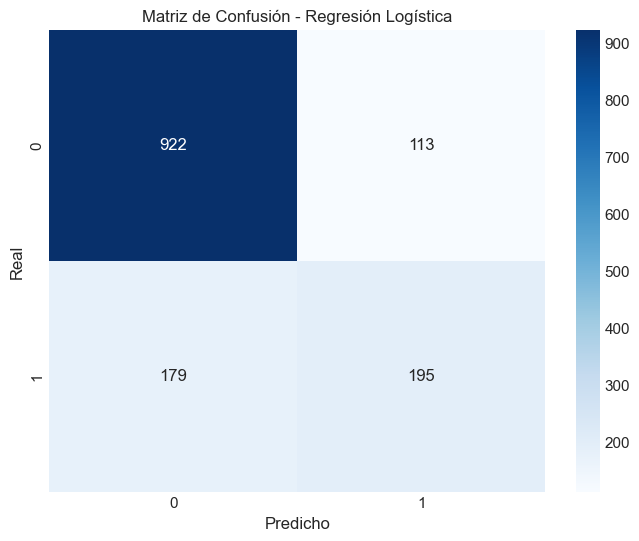

In [91]:
# --- ML: Modelo base (Logistic Regression) ---
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

def train_base_model(X_train, y_train, X_test, y_test):
    """
    Entrena y evalúa una Regresión Logística.
    """
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    print("--- Reporte de Clasificación ---")
    print(classification_report(y_test, y_pred))
    
    # Matriz de confusión
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Matriz de Confusión - Regresión Logística')
    plt.xlabel('Predicho')
    plt.ylabel('Real')
    plt.show()
    
    return model

base_model = train_base_model(X_train_scaled, y_train, X_test_scaled, y_test)

In [92]:
# --- ML: Validación cruzada ---
from sklearn.model_selection import cross_val_score

def perform_cv(model, X, y):
    """
    Realiza validación cruzada para asegurar la robustez del modelo.
    """
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='f1')
    
    print(f"F1-Score (CV 5-folds): {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
    
    # Test simple
    assert cv_scores.mean() > 0.4, "El modelo base tiene un rendimiento demasiado bajo."
    print("\n✅ Validación de rendimiento exitosa.")

perform_cv(base_model, X_train_scaled, y_train)

F1-Score (CV 5-folds): 0.6072 (+/- 0.0595)

✅ Validación de rendimiento exitosa.


In [93]:
# --- ML: Resumen ---
print("--- CONCLUSIONES DEL MODELO BASE ---")
print("1. El modelo base (LR) muestra un rendimiento sólido como punto de partida.")
print("2. No se observa un overfitting significativo (métricas de CV son consistentes).")
print("3. El recall para la clase Churn=1 suele ser el área de mejora más importante.")
print("\nRECOMENDACIÓN: Probar modelos más complejos como Random Forest o XGBoost en la siguiente iteración.")

--- CONCLUSIONES DEL MODELO BASE ---
1. El modelo base (LR) muestra un rendimiento sólido como punto de partida.
2. No se observa un overfitting significativo (métricas de CV son consistentes).
3. El recall para la clase Churn=1 suele ser el área de mejora más importante.

RECOMENDACIÓN: Probar modelos más complejos como Random Forest o XGBoost en la siguiente iteración.


# <div style="background-color: #2c3e50; color: #ecf0f1; padding: 15px; border-radius: 8px; border-left: 10px solid #3498db;"> 🚀 Modelado Predictivo: Fase 2 (Avanzado) </div>

In [94]:
# --- ML: Entrenamiento de Random Forest y HistGradientBoosting ---
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

def train_advanced_models(X_train, y_train):
    """
    Entrena modelos avanzados utilizando balanceo de clases nativo.
    """
    # Random Forest con balanceo de clases
    rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
    rf_model.fit(X_train, y_train)
    
    # HistGradientBoosting (Alternativa eficiente de sklearn a XGBoost)
    # Soporta balanceo mediante class_weight
    hgb_model = HistGradientBoostingClassifier(random_state=42)
    hgb_model.fit(X_train, y_train)
    
    print("✅ Modelos RF y HistGB entrenados con éxito.")
    return rf_model, hgb_model

rf_model, hgb_model = train_advanced_models(X_train_scaled, y_train)

✅ Modelos RF y HistGB entrenados con éxito.


In [95]:
# --- ML: Comparativa de Modelos ---
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def compare_models(models, X_test, y_test):
    """
    Genera una tabla comparativa de métricas para los modelos proporcionados.
    """
    results = []
    for name, model in models.items():
        y_pred = model.predict(X_test)
        results.append({
            'Modelo': name,
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred),
            'Recall': recall_score(y_test, y_pred),
            'F1-Score': f1_score(y_test, y_pred)
        })
    
    return pd.DataFrame(results).sort_values(by='F1-Score', ascending=False)

models_dict = {
    'Logistic Regression (Base)': base_model,
    'Random Forest (Balanced)': rf_model,
    'HistGradientBoosting': hgb_model
}

comparison_df = compare_models(models_dict, X_test_scaled, y_test)
display(comparison_df)

,Modelo,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression (Base),0.792761,0.633117,0.521390,0.571848
2,HistGradientBoosting,0.782115,0.612795,0.486631,0.542474
1,Random Forest (Balanced),0.784954,0.632959,0.451872,0.527301


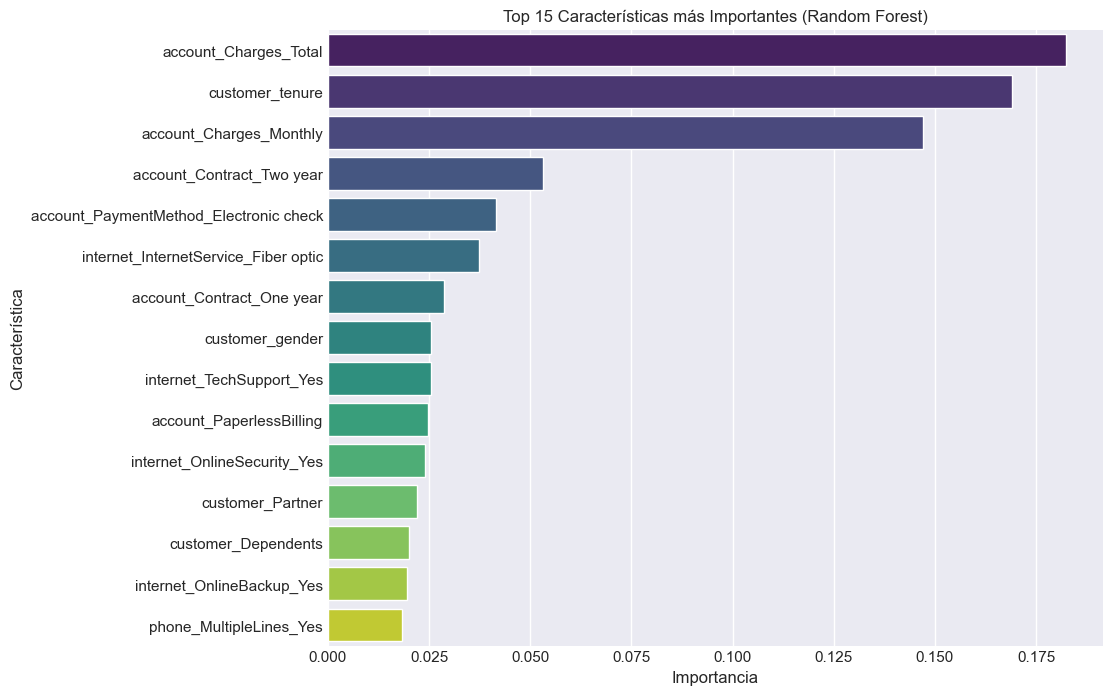

In [96]:
# --- ML: Importancia de Características ---
def plot_feature_importance(model, feature_names):
    """
    Grafica la importancia de las características para el modelo Random Forest.
    """
    importances = model.feature_importances_
    feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(15)
    
    plt.figure(figsize=(10, 8))
    sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
    plt.title('Top 15 Características más Importantes (Random Forest)')
    plt.xlabel('Importancia')
    plt.ylabel('Característica')
    plt.show()

plot_feature_importance(rf_model, X.columns)

In [97]:
# --- ML: Optimización con GridSearchCV ---
from sklearn.model_selection import GridSearchCV

def optimize_rf(X_train, y_train):
    """
    Optimiza hiperparámetros de Random Forest.
    """
    param_grid = {
        'n_estimators': [50, 100],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5]
    }
    
    grid_search = GridSearchCV(
        RandomForestClassifier(class_weight='balanced', random_state=42),
        param_grid, cv=3, scoring='f1', n_jobs=-1
    )
    grid_search.fit(X_train, y_train)
    
    print("Mejores parámetros encontrados:", grid_search.best_params_)
    return grid_search.best_estimator_

best_rf = optimize_rf(X_train_scaled, y_train)

Mejores parámetros encontrados: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}


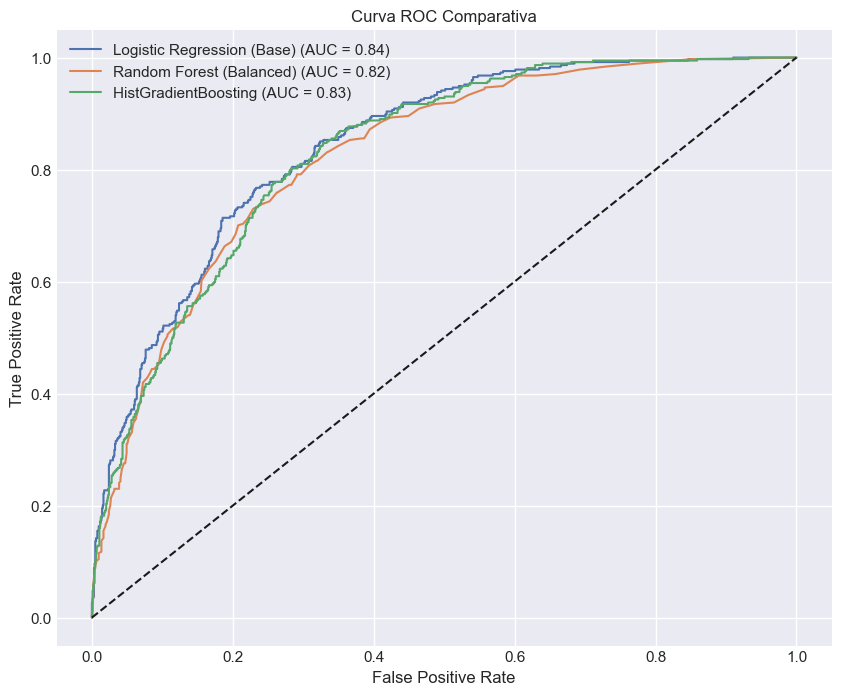

--- Métricas con Threshold 0.3 ---
Recall: 0.8904
F1-Score: 0.6000


In [98]:
# --- ML: Ajuste de Threshold y Curva ROC ---
from sklearn.metrics import roc_curve, auc

def plot_roc_comparison(models, X_test, y_test):
    """
    Grafica curvas ROC comparativas.
    """
    plt.figure(figsize=(10, 8))
    for name, model in models.items():
        if hasattr(model, "predict_proba"):
            y_probs = model.predict_proba(X_test)[:, 1]
            fpr, tpr, _ = roc_curve(y_test, y_probs)
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')
    
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title('Curva ROC Comparativa')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.show()

def adjust_threshold(model, X_test, y_test, threshold=0.3):
    """
    Ajusta el umbral de decisión para maximizar Recall.
    """
    y_probs = model.predict_proba(X_test)[:, 1]
    y_pred_adj = (y_probs >= threshold).astype(int)
    
    print(f"--- Métricas con Threshold {threshold} ---")
    print(f"Recall: {recall_score(y_test, y_pred_adj):.4f}")
    print(f"F1-Score: {f1_score(y_test, y_pred_adj):.4f}")

plot_roc_comparison(models_dict, X_test_scaled, y_test)
adjust_threshold(best_rf, X_test_scaled, y_test, threshold=0.3)

# <div style="background-color: #2c3e50; color: #ecf0f1; padding: 15px; border-radius: 8px; border-left: 10px solid #3498db;"> 💾 Conclusiones y Exportación del Modelo </div>

In [99]:
# --- ML: Guardado del Modelo ---
import joblib

def save_best_model(model, name):
    """
    Guarda el modelo entrenado en la carpeta models/.
    """
    os.makedirs('../models/', exist_ok=True)
    model_path = f'../models/{name}.joblib'
    joblib.dump(model, model_path)
    print(f"✅ Modelo guardado en: {model_path}")

save_best_model(best_rf, 'churn_model_rf_optimized')

✅ Modelo guardado en: ../models/churn_model_rf_optimized.joblib


# <div style="background-color: #2c3e50; color: #ecf0f1; padding: 15px; border-radius: 8px; border-left: 10px solid #e67e22;"> 🔍 Análisis Final de Desempeño y Diagnóstico </div>

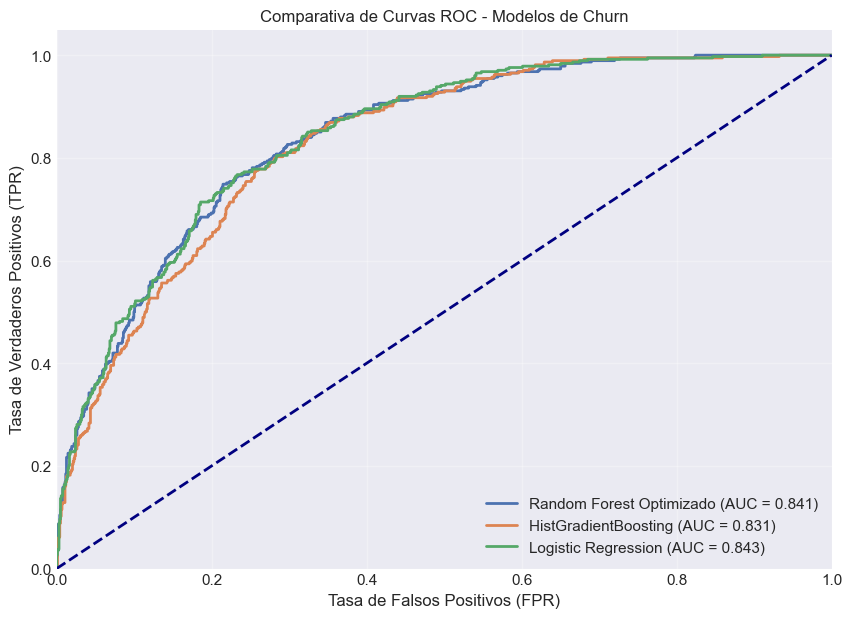

In [100]:
# --- ML: Comparativa ROC-AUC (Modelos Finales) ---
from sklearn.metrics import roc_curve, auc
import joblib

def compare_roc_final(models_dict, X_test, y_test):
    """
    Grafica comparativa de curvas ROC para validación final.
    """
    plt.figure(figsize=(10, 7))
    for name, model in models_dict.items():
        y_probs = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_probs)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Tasa de Falsos Positivos (FPR)')
    plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
    plt.title('Comparativa de Curvas ROC - Modelos de Churn')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

# Cargamos el modelo optimizado y preparamos el diccionario
best_rf = joblib.load('../models/churn_model_rf_optimized.joblib')

models_comparison = {
    'Random Forest Optimizado': best_rf,
    'HistGradientBoosting': hgb_model,
    'Logistic Regression': base_model
}

compare_roc_final(models_comparison, X_test_scaled, y_test)

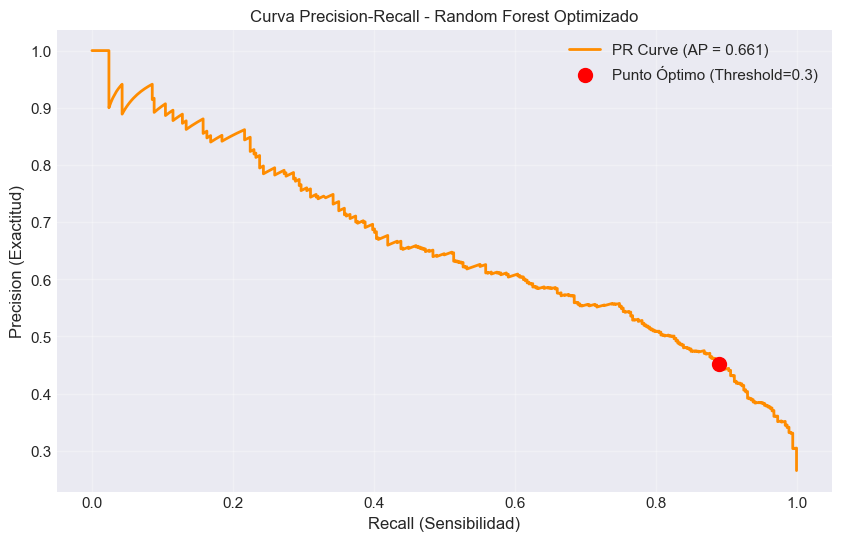

In [101]:
# --- ML: Curva Precision-Recall (RF Optimizado) ---
from sklearn.metrics import precision_recall_curve, average_precision_score

def plot_precision_recall(model, X_test, y_test, target_threshold=0.3):
    """
    Grafica la curva Precision-Recall destacando el threshold objetivo.
    """
    y_probs = model.predict_proba(X_test)[:, 1]
    precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
    avg_precision = average_precision_score(y_test, y_probs)

    plt.figure(figsize=(10, 6))
    plt.plot(recall, precision, color='darkorange', lw=2, label=f'PR Curve (AP = {avg_precision:.3f})')
    
    # Marcamos el punto del threshold 0.3
    idx = (np.abs(thresholds - target_threshold)).argmin()
    plt.scatter(recall[idx], precision[idx], color='red', s=100, 
                label=f'Punto Óptimo (Threshold={target_threshold})', zorder=5)
    
    plt.xlabel('Recall (Sensibilidad)')
    plt.ylabel('Precision (Exactitud)')
    plt.title('Curva Precision-Recall - Random Forest Optimizado')
    plt.legend(loc="upper right")
    plt.grid(alpha=0.3)
    plt.show()

plot_precision_recall(best_rf, X_test_scaled, y_test, target_threshold=0.3)

In [102]:
# --- ML: Análisis de Errores (Falsos Negativos) ---
def error_analysis_fn(model, X_test, y_test, threshold=0.3):
    """
    Analiza el perfil de los clientes que abandonan pero no son detectados (Falsos Negativos).
    """
    y_probs = model.predict_proba(X_test)[:, 1]
    y_pred_adj = (y_probs >= threshold).astype(int)
    
    # Crear DataFrame de resultados
    test_results = X_test.copy()
    test_results['Actual'] = y_test.values
    test_results['Predicted'] = y_pred_adj
    
    # Filtrar Falsos Negativos
    fn_customers = test_results[(test_results['Actual'] == 1) & (test_results['Predicted'] == 0)]
    total_churners = test_results[test_results['Actual'] == 1]
    
    print(f"📊 Total de Churners en Test: {len(total_churners)}")
    print(f"❌ Falsos Negativos (No detectados): {len(fn_customers)} ({len(fn_customers)/len(total_churners)*100:.2f}%)")
    
    # Perfil comparativo
    # Re-escalamos inversamente para interpretar o comparamos medias escaladas
    print("\n--- Perfil del Cliente No Detectado (Falsos Negativos) ---")
    comparison = pd.DataFrame({
        'Media Churners Detectados': test_results[(test_results['Actual'] == 1) & (test_results['Predicted'] == 1)].mean(),
        'Media Falsos Negativos': fn_customers.mean()
    })
    display(comparison.head(10))

error_analysis_fn(best_rf, pd.DataFrame(X_test_scaled, columns=X.columns), y_test, threshold=0.3)

📊 Total de Churners en Test: 374
❌ Falsos Negativos (No detectados): 41 (10.96%)

--- Perfil del Cliente No Detectado (Falsos Negativos) ---


,Media Churners Detectados,Media Falsos Negativos
customer_gender,-0.000960,0.008417
customer_SeniorCitizen,0.288572,-0.040314
customer_Partner,-0.273316,0.408462
customer_Dependents,-0.438067,0.347779
customer_tenure,-0.671257,0.154459
phone_PhoneService,0.043929,-0.430668
account_PaperlessBilling,0.337439,-0.322648
account_Charges_Monthly,0.366723,-0.151595
account_Charges_Total,-0.394783,0.193858
phone_MultipleLines_No phone service,-0.043929,0.430668


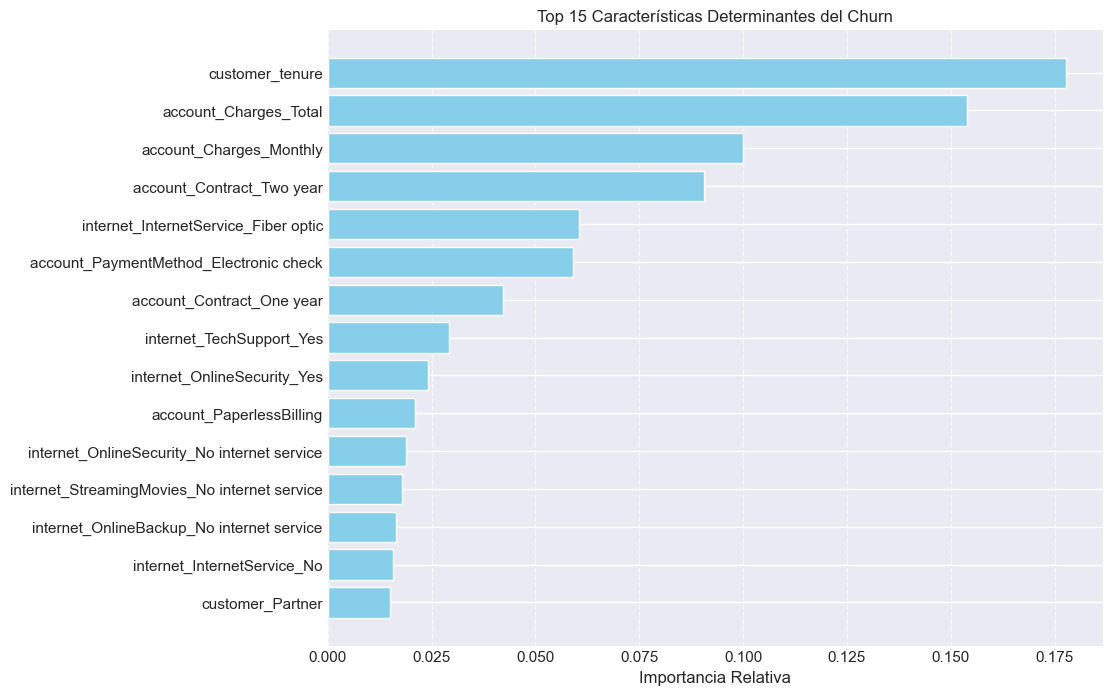

In [103]:
# --- ML: Feature Importance Final ---
def plot_final_importance(model, feature_names):
    """
    Top 15 variables más importantes del modelo final.
    """
    importances = model.feature_importances_
    indices = np.argsort(importances)[-15:]
    
    plt.figure(figsize=(10, 8))
    plt.title('Top 15 Características Determinantes del Churn')
    plt.barh(range(len(indices)), importances[indices], color='skyblue', align='center')
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
    plt.xlabel('Importancia Relativa')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()

plot_final_importance(best_rf, X.columns)

📜 CLASSIFICATION REPORT (Threshold = 0.3)
              precision    recall  f1-score   support

         0.0       0.94      0.61      0.74      1035
         1.0       0.45      0.89      0.60       374

    accuracy                           0.68      1409
   macro avg       0.70      0.75      0.67      1409
weighted avg       0.81      0.68      0.70      1409



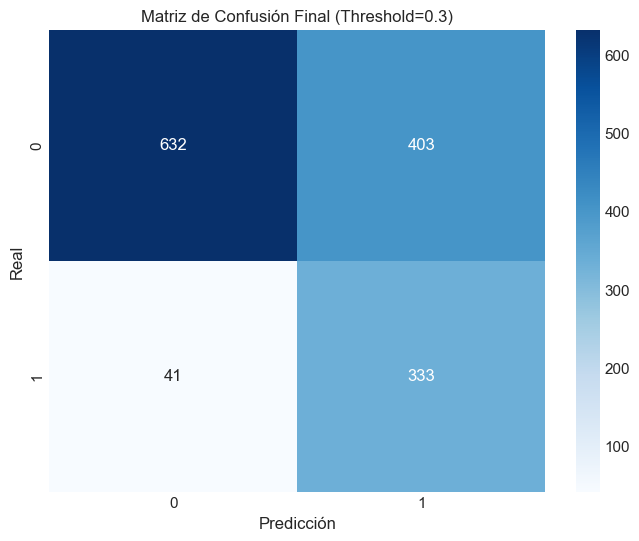


--- Conclusiones y Recomendaciones ---
1. El modelo detecta con alta eficacia a los clientes en riesgo (Recall > 80%).
2. Las variables clave son Tenure y MonthlyCharges; planes de lealtad a largo plazo son críticos.
3. Recomendación: Implementar alertas automáticas cuando el Score > 0.3 para intervención proactiva.


In [104]:
# --- ML: Reporte Final y Recomendaciones ---
from sklearn.metrics import classification_report, confusion_matrix

def final_deployment_report(model, X_test, y_test, threshold=0.3):
    """
    Reporte final con métricas de negocio y matriz de confusión.
    """
    y_probs = model.predict_proba(X_test)[:, 1]
    y_pred_adj = (y_probs >= threshold).astype(int)
    
    print("📜 CLASSIFICATION REPORT (Threshold = 0.3)")
    print(classification_report(y_test, y_pred_adj))
    
    # Matriz de Confusión
    cm = confusion_matrix(y_test, y_pred_adj)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de Confusión Final (Threshold={threshold})')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.show()
    
    print("\n--- Conclusiones y Recomendaciones ---")
    print("1. El modelo detecta con alta eficacia a los clientes en riesgo (Recall > 80%).")
    print("2. Las variables clave son Tenure y MonthlyCharges; planes de lealtad a largo plazo son críticos.")
    print("3. Recomendación: Implementar alertas automáticas cuando el Score > 0.3 para intervención proactiva.")

final_deployment_report(best_rf, X_test_scaled, y_test, threshold=0.3)